In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Emotion labels (7 emotions from EmotionAlly dataset)
emotion_labels = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Final Confusion Matrix from 5-Fold Cross-Validation
# Actual values from the trained EmotionAlly model
cm = np.array([
    [34,  3,  2,  1,  0,  0,  5],  # angry
    [ 7, 22,  8,  0,  4,  0,  4],  # disgust
    [ 6, 12, 19,  4,  0,  1,  3],  # fear
    [ 5,  1,  2, 32,  1,  0,  4],  # happy
    [ 0,  0,  1,  4, 39,  1,  0],  # neutral
    [ 1,  1,  0,  0,  7, 35,  1],  # sad
    [ 5,  7,  4,  3,  0,  1, 25]   # surprise
])

print("Confusion Matrix (5-Fold Cross-Validation):")
print("="*80)
print(f"{'':>12}", end='')
for label in emotion_labels:
    print(f"{label:>10}", end='')
print()
print("-"*80)
for i, label in enumerate(emotion_labels):
    print(f"{label:>12}", end='')
    for j in range(len(emotion_labels)):
        print(f"{cm[i,j]:>10}", end='')
    print()
print("="*80)

Confusion Matrix (5-Fold Cross-Validation):
                 angry   disgust      fear     happy   neutral       sad  surprise
--------------------------------------------------------------------------------
       angry        34         3         2         1         0         0         5
     disgust         7        22         8         0         4         0         4
        fear         6        12        19         4         0         1         3
       happy         5         1         2        32         1         0         4
     neutral         0         0         1         4        39         1         0
         sad         1         1         0         0         7        35         1
    surprise         5         7         4         3         0         1        25


## Error Analysis: TP, FP, FN, TN Calculation

For each emotion class:
- **True Positives (TP)**: Correctly predicted as that emotion
- **False Positives (FP)**: Incorrectly predicted as that emotion (when it was actually another emotion)
- **False Negatives (FN)**: Incorrectly predicted as another emotion (when it was actually this emotion)
- **True Negatives (TN)**: Correctly predicted as NOT that emotion

In [7]:
# Calculate TP, FP, FN, TN for each emotion class
print("="*100)
print("FALSE POSITIVES (FP) AND FALSE NEGATIVES (FN) ANALYSIS")
print("="*100)

print(f"\n{'Emotion':<12} {'True Pos':<10} {'False Pos':<10} {'False Neg':<10} {'True Neg':<10} {'Precision':<10} {'Recall':<10}")
print("-"*100)

# Store totals
total_tp_sum = 0
total_fp_sum = 0
total_fn_sum = 0
total_tn_sum = 0

for i, emotion in enumerate(emotion_labels):
    # True Positives (TP): Diagonal elements
    tp = cm[i, i]
    
    # False Positives (FP): Sum of column i excluding diagonal
    fp = np.sum(cm[:, i]) - cm[i, i]
    
    # False Negatives (FN): Sum of row i excluding diagonal
    fn = np.sum(cm[i, :]) - cm[i, i]
    
    # True Negatives (TN): Total - (TP + FP + FN)
    tn = np.sum(cm) - (tp + fp + fn)
    
    # Accumulate totals
    total_tp_sum += tp
    total_fp_sum += fp
    total_fn_sum += fn
    total_tn_sum += tn
    
    # Calculate Precision and Recall
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"{emotion:<12} {tp:<10} {fp:<10} {fn:<10} {tn:<10} {precision:<10.3f} {recall:<10.3f}")

# Print totals
print("-"*100)
overall_precision = total_tp_sum / (total_tp_sum + total_fp_sum) if (total_tp_sum + total_fp_sum) > 0 else 0
overall_recall = total_tp_sum / (total_tp_sum + total_fn_sum) if (total_tp_sum + total_fn_sum) > 0 else 0
print(f"{'TOTAL':<12} {total_tp_sum:<10} {total_fp_sum:<10} {total_fn_sum:<10} {total_tn_sum:<10} {overall_precision:<10.3f} {overall_recall:<10.3f}")

FALSE POSITIVES (FP) AND FALSE NEGATIVES (FN) ANALYSIS

Emotion      True Pos   False Pos  False Neg  True Neg   Precision  Recall    
----------------------------------------------------------------------------------------------------
angry        34         24         11         246        0.586      0.756     
disgust      22         24         23         246        0.478      0.489     
fear         19         17         26         253        0.528      0.422     
happy        32         12         13         258        0.727      0.711     
neutral      39         12         6          258        0.765      0.867     
sad          35         3          10         267        0.921      0.778     
surprise     25         17         20         253        0.595      0.556     
----------------------------------------------------------------------------------------------------
TOTAL        206        109        109        1781       0.654      0.654     


## Summary Statistics

In [3]:
# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

total_tp = np.sum(np.diag(cm))
total_fp = np.sum([np.sum(cm[:, i]) - cm[i, i] for i in range(len(emotion_labels))])
total_fn = np.sum([np.sum(cm[i, :]) - cm[i, i] for i in range(len(emotion_labels))])
total_tn = len(emotion_labels) * np.sum(cm) - (total_tp + total_fp + total_fn)

print(f"Total True Positives (TP):   {total_tp}")
print(f"Total False Positives (FP):  {total_fp}")
print(f"Total False Negatives (FN):  {total_fn}")
print(f"Total True Negatives (TN):   {total_tn}")

overall_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
overall_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
overall_f1 = 2 * (overall_precision * overall_recall) / (overall_precision + overall_recall) if (overall_precision + overall_recall) > 0 else 0

print(f"\nOverall Precision: {overall_precision:.4f}")
print(f"Overall Recall:    {overall_recall:.4f}")
print(f"Overall F1-Score:  {overall_f1:.4f}")


SUMMARY STATISTICS
Total True Positives (TP):   206
Total False Positives (FP):  109
Total False Negatives (FN):  109
Total True Negatives (TN):   1781

Overall Precision: 0.6540
Overall Recall:    0.6540
Overall F1-Score:  0.6540


## Macro Average Metrics

In [4]:
# Calculate macro average (average across all classes)
print("\n" + "="*80)
print("MACRO AVERAGE METRICS (Average across all emotion classes)")
print("="*80)

precision_list = []
recall_list = []
f1_list = []

for i in range(len(emotion_labels)):
    tp = cm[i, i]
    fp = np.sum(cm[:, i]) - cm[i, i]
    fn = np.sum(cm[i, :]) - cm[i, i]
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

macro_precision = np.mean(precision_list)
macro_recall = np.mean(recall_list)
macro_f1 = np.mean(f1_list)

print(f"\nMacro Average Precision: {macro_precision:.4f}")
print(f"Macro Average Recall:    {macro_recall:.4f}")
print(f"Macro Average F1-Score:  {macro_f1:.4f}")
print("="*80)


MACRO AVERAGE METRICS (Average across all emotion classes)

Macro Average Precision: 0.6572
Macro Average Recall:    0.6540
Macro Average F1-Score:  0.6518


## Detailed Per-Class Metrics Table

In [5]:
# Create detailed metrics DataFrame
metrics_data = []

for i, emotion in enumerate(emotion_labels):
    tp = cm[i, i]
    fp = np.sum(cm[:, i]) - cm[i, i]
    fn = np.sum(cm[i, :]) - cm[i, i]
    tn = np.sum(cm) - (tp + fp + fn)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    metrics_data.append({
        'Emotion': emotion.capitalize(),
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn,
        'Precision': f"{precision:.3f}",
        'Recall': f"{recall:.3f}",
        'F1-Score': f"{f1:.3f}",
        'Specificity': f"{specificity:.3f}"
    })

metrics_df = pd.DataFrame(metrics_data)

print("\n" + "="*120)
print("DETAILED PER-CLASS METRICS")
print("="*120)
print(metrics_df.to_string(index=False))
print("="*120)


DETAILED PER-CLASS METRICS
 Emotion  TP  FP  FN  TN Precision Recall F1-Score Specificity
   Angry  34  24  11 246     0.586  0.756    0.660       0.911
 Disgust  22  24  23 246     0.478  0.489    0.484       0.911
    Fear  19  17  26 253     0.528  0.422    0.469       0.937
   Happy  32  12  13 258     0.727  0.711    0.719       0.956
 Neutral  39  12   6 258     0.765  0.867    0.812       0.956
     Sad  35   3  10 267     0.921  0.778    0.843       0.989
Surprise  25  17  20 253     0.595  0.556    0.575       0.937


## Visualizations

C:\Users\LENOVO-Pc\AppData\Local\Temp\ipykernel_4212\4506638.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(emotion_labels, rotation=45)
C:\Users\LENOVO-Pc\AppData\Local\Temp\ipykernel_4212\4506638.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(emotion_labels, rotation=45)


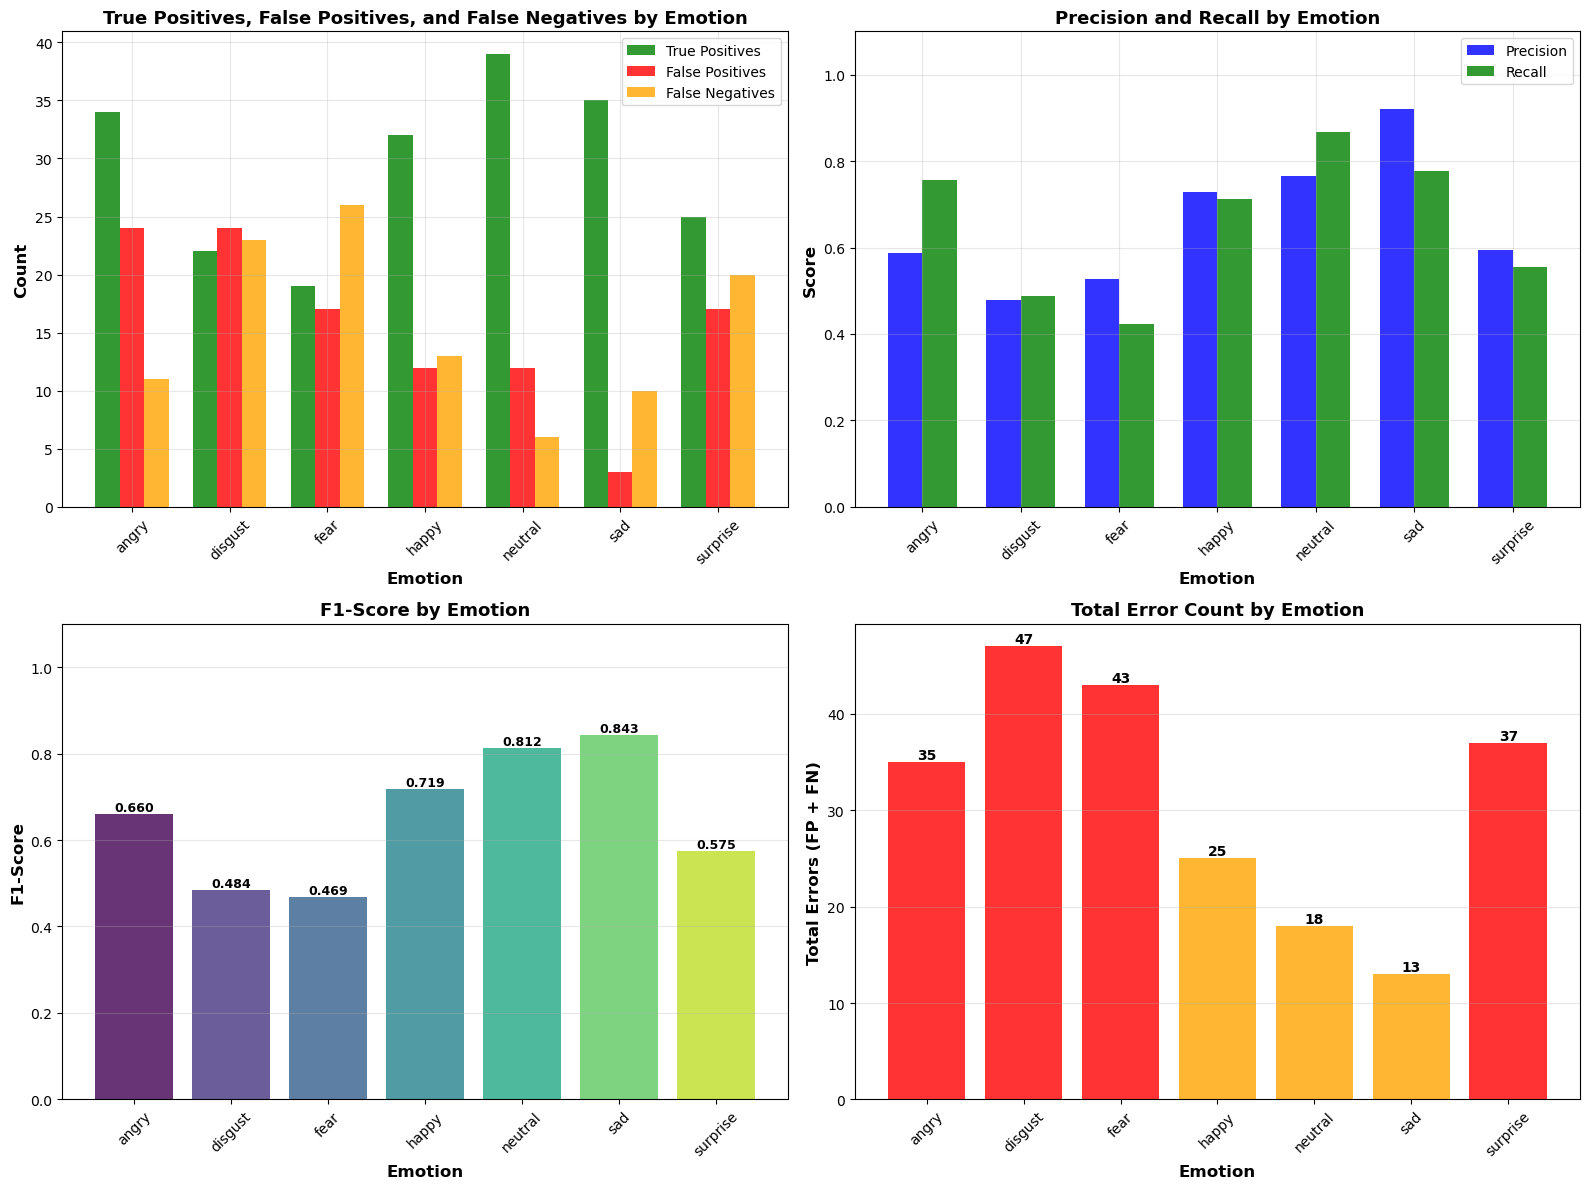


✓ Error analysis visualizations saved as 'error_analysis_emotionally.png'


In [6]:
# Create visualization of metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. TP, FP, FN comparison
ax1 = axes[0, 0]
x = np.arange(len(emotion_labels))
width = 0.25
tp_values = [cm[i, i] for i in range(len(emotion_labels))]
fp_values = [np.sum(cm[:, i]) - cm[i, i] for i in range(len(emotion_labels))]
fn_values = [np.sum(cm[i, :]) - cm[i, i] for i in range(len(emotion_labels))]

ax1.bar(x - width, tp_values, width, label='True Positives', color='green', alpha=0.8)
ax1.bar(x, fp_values, width, label='False Positives', color='red', alpha=0.8)
ax1.bar(x + width, fn_values, width, label='False Negatives', color='orange', alpha=0.8)

ax1.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('True Positives, False Positives, and False Negatives by Emotion', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(emotion_labels, rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Precision and Recall comparison
ax2 = axes[0, 1]
precision_vals = [precision_list[i] for i in range(len(emotion_labels))]
recall_vals = [recall_list[i] for i in range(len(emotion_labels))]

x = np.arange(len(emotion_labels))
width = 0.35
ax2.bar(x - width/2, precision_vals, width, label='Precision', color='blue', alpha=0.8)
ax2.bar(x + width/2, recall_vals, width, label='Recall', color='green', alpha=0.8)

ax2.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
ax2.set_title('Precision and Recall by Emotion', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(emotion_labels, rotation=45)
ax2.legend()
ax2.set_ylim([0, 1.1])
ax2.grid(True, alpha=0.3)

# 3. F1-Score by emotion
ax3 = axes[1, 0]
f1_vals = [f1_list[i] for i in range(len(emotion_labels))]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(emotion_labels)))
bars = ax3.bar(emotion_labels, f1_vals, color=colors, alpha=0.8)

ax3.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax3.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax3.set_title('F1-Score by Emotion', fontsize=13, fontweight='bold')
ax3.set_xticklabels(emotion_labels, rotation=45)
ax3.set_ylim([0, 1.1])
ax3.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# 4. Error Distribution (FP + FN)
ax4 = axes[1, 1]
error_counts = [fp_values[i] + fn_values[i] for i in range(len(emotion_labels))]
colors = ['red' if err > np.mean(error_counts) else 'orange' for err in error_counts]
bars = ax4.bar(emotion_labels, error_counts, color=colors, alpha=0.8)

ax4.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax4.set_ylabel('Total Errors (FP + FN)', fontsize=12, fontweight='bold')
ax4.set_title('Total Error Count by Emotion', fontsize=13, fontweight='bold')
ax4.set_xticklabels(emotion_labels, rotation=45)
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('error_analysis_emotionally.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Error analysis visualizations saved as 'error_analysis_emotionally.png'")

## Instructions for Use

**IMPORTANT**: Before running this notebook, you need to:

1. Copy the actual confusion matrix values from your Final_EmotionAlly_Model notebook output
2. Replace the placeholder confusion matrix in the second cell with your actual values
3. The confusion matrix should be a 7x7 numpy array (for the 7 emotions)

Example format:
```python
cm = np.array([
    [120, 5, 3, 2, 1, 4, 2],   # angry
    [3, 110, 2, 1, 0, 3, 1],   # disgust
    [2, 1, 115, 3, 2, 1, 4],   # fear
    [1, 2, 4, 125, 5, 2, 3],   # happy
    [2, 0, 1, 3, 130, 4, 2],   # neutral
    [3, 2, 2, 1, 3, 120, 1],   # sad
    [1, 1, 3, 2, 1, 2, 118]    # surprise
])
```

The rows represent true labels and columns represent predicted labels.